# Level 2 - Task 1: Regression Analysis

## Objective

The objective of this task is to build a Regression model to predict a continuous target variable using Machine Learning techniques. This notebook includes data loading, preprocessing, model training, prediction, and performance evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Step 1: Load the House Prediction Dataset

In this step, I load the House Prediction dataset into a Pandas DataFrame for regression analysis.

In [12]:
df = pd.read_csv(
    "C:/Users/asdf/Desktop/Codeeda _Data_Analytics/Level_2/4) house Prediction Data Set.csv",
    sep=r"\s+",
    header=None,
    engine="python"
)

## Step 2: Display the First Five Rows

In [13]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Step 3: Check Dataset Information


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       506 non-null    float64
 1   1       506 non-null    float64
 2   2       506 non-null    float64
 3   3       506 non-null    int64  
 4   4       506 non-null    float64
 5   5       506 non-null    float64
 6   6       506 non-null    float64
 7   7       506 non-null    float64
 8   8       506 non-null    int64  
 9   9       506 non-null    float64
 10  10      506 non-null    float64
 11  11      506 non-null    float64
 12  12      506 non-null    float64
 13  13      506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## Step 4: Check Dataset Shape

In [15]:
df.shape

(506, 14)

## Step 5: Summary Statistics

In [16]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Step 6: Assign Column Names

In [17]:
df.columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX",
    "RM", "AGE", "DIS", "RAD", "TAX",
    "PTRATIO", "B", "LSTAT", "MEDV"
]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Step 7: Separate Features and Target Variable

The dataset is divided into:
Features (X): Independent variables used for prediction.
Target (y):The house price (`MEDV`) that the model will predict.

In [18]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (506, 13)
Target Shape: (506,)


## Step 8: Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets.
Training data (80%)is used to train the Linear Regression model.
Testing data (20%) is used to evaluate the model's performance on unseen data.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (404, 13)
Testing Features: (102, 13)
Training Target: (404,)
Testing Target: (102,)


## Step 9: Import the Linear Regression Model

Import the Linear Regression algorithm from Scikit-learn to build a regression model for predicting house prices.

In [20]:
from sklearn.linear_model import LinearRegression

## Step 10: Train the Linear Regression Model

Create a Linear Regression model and train it using the training dataset. The model learns the relationship between the input features and the target variable (house price).

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Step 11: Make Predictions

Use the trained Linear Regression model to predict house prices for the test dataset.

In [22]:
y_pred = model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


## Step 12: Evaluate the Regression Model

Evaluate the performance of the Linear Regression model using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R-squared (R² Score)

These metrics help measure the accuracy and performance of the regression model.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R-squared (R² Score):", round(r2, 2))

Mean Absolute Error (MAE): 3.19
Mean Squared Error (MSE): 24.29
Root Mean Squared Error (RMSE): 4.93
R-squared (R² Score): 0.67


## Step 13: Visualize Actual vs Predicted Values

Create a scatter plot to compare the actual house prices with the predicted house prices. This visualization helps evaluate how closely the model's predictions match the actual values.

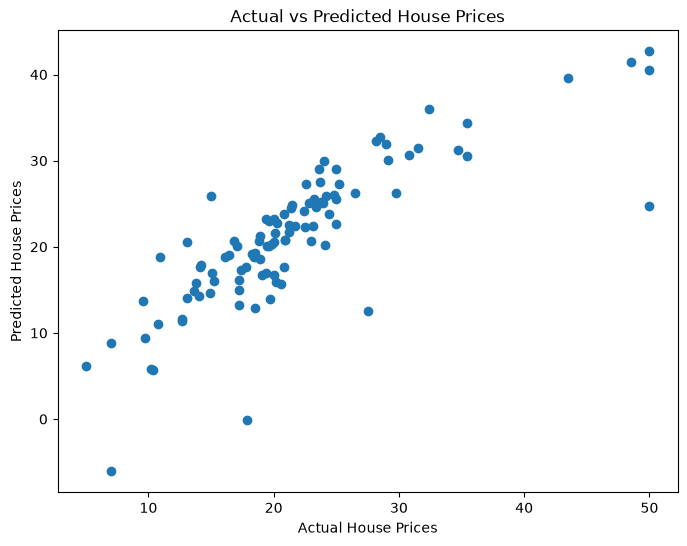

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Conclusion

In this project, a Linear Regression model was developed to predict house prices using the Boston Housing dataset.

The dataset was successfully loaded, explored, and prepared for machine learning. The data was divided into training and testing sets, and a Linear Regression model was trained using the training data.

The model achieved the following performance:

- Mean Absolute Error (MAE): 3.19
- Mean Squared Error (MSE): 24.29
- Root Mean Squared Error (RMSE): 4.93
- R-squared (R² Score): 0.67

The scatter plot comparing actual and predicted house prices shows that the model provides reasonably accurate predictions with a positive relationship between actual and predicted values.

Overall, the Linear Regression model demonstrates good baseline performance for house price prediction and provides a strong foundation for regression analysis.